12/12 [==============================] - 1s 7ms/step


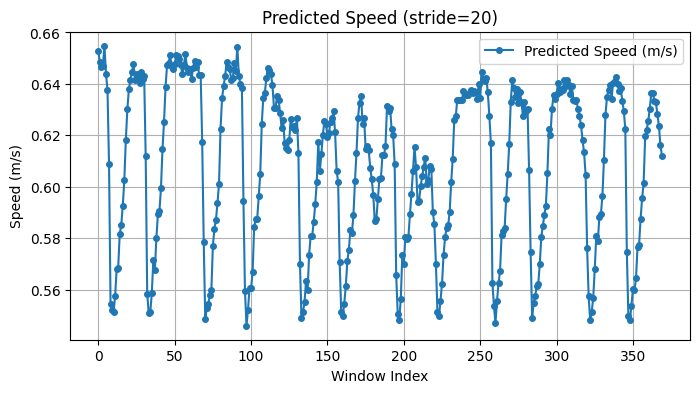

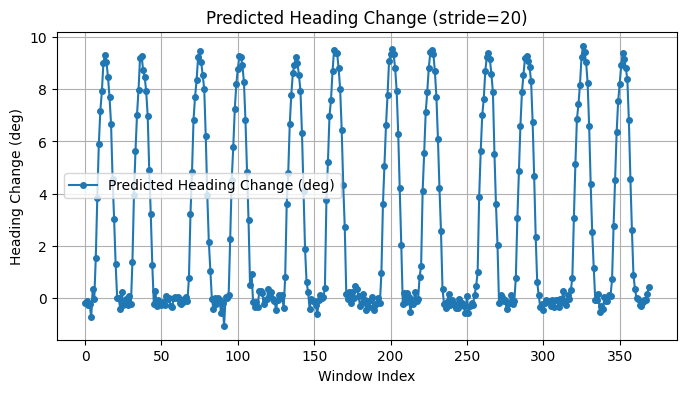

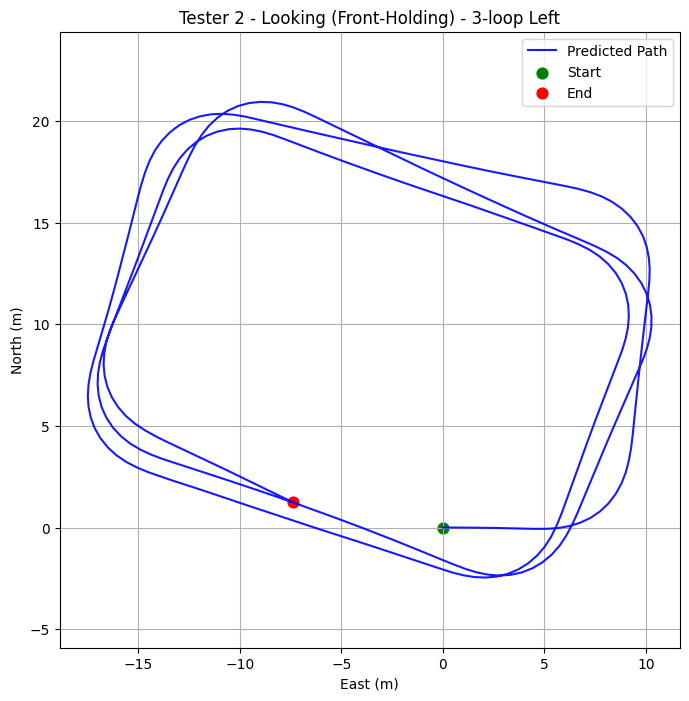

Start-End distance: 7.464 m
Heading Error (deg): -25.525 deg


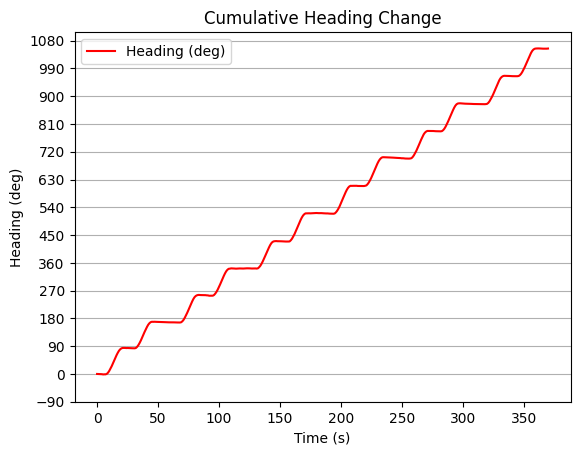

12/12 [==============================] - 0s 7ms/step


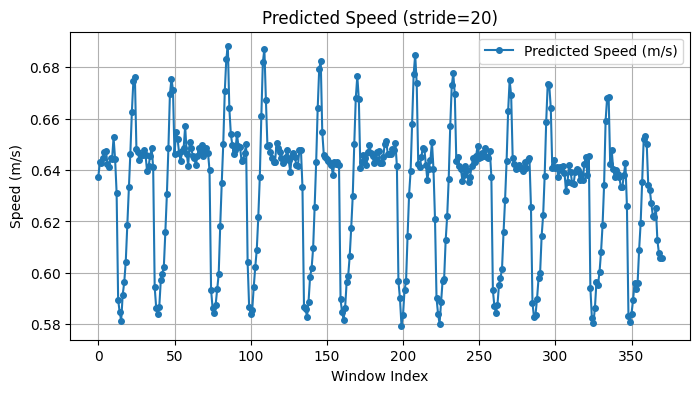

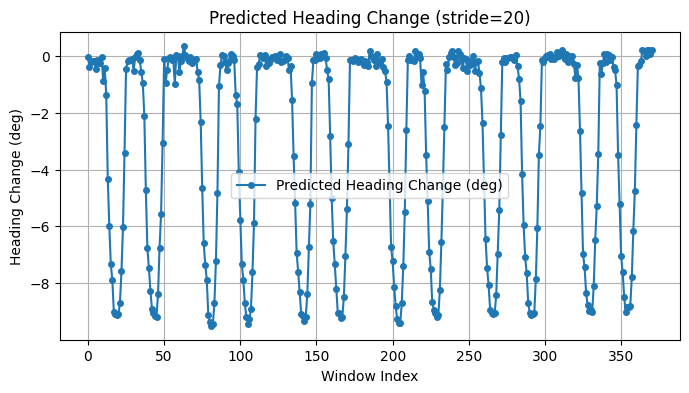

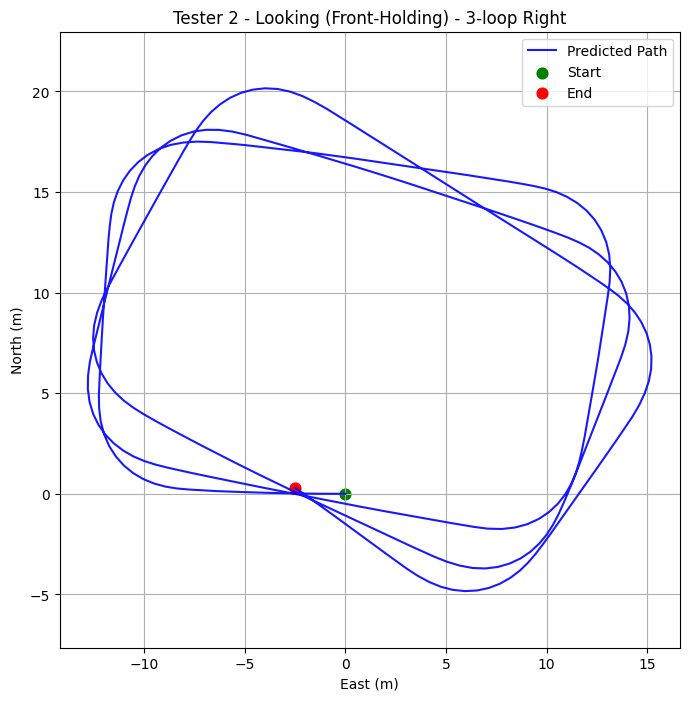

Start-End distance: 2.518 m
Heading Error (deg): 35.383 deg


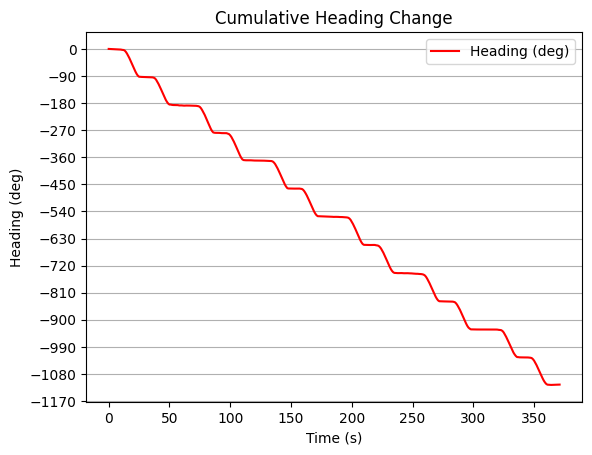

12/12 [==============================] - 0s 7ms/step


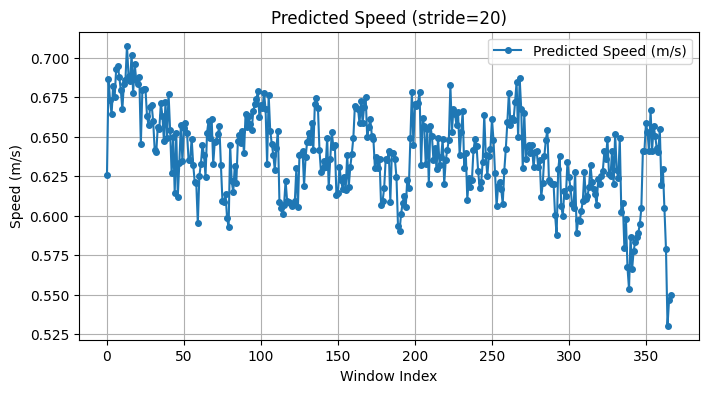

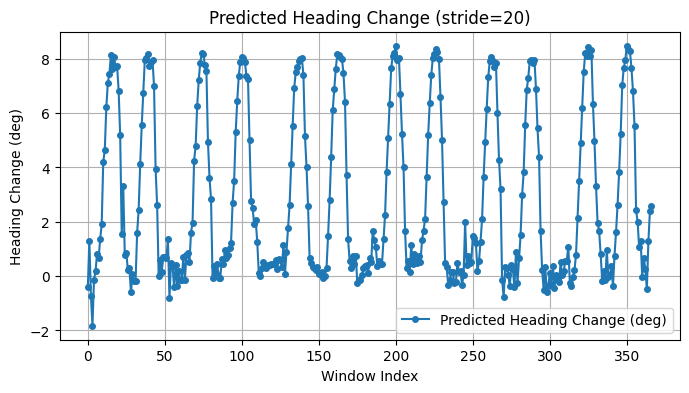

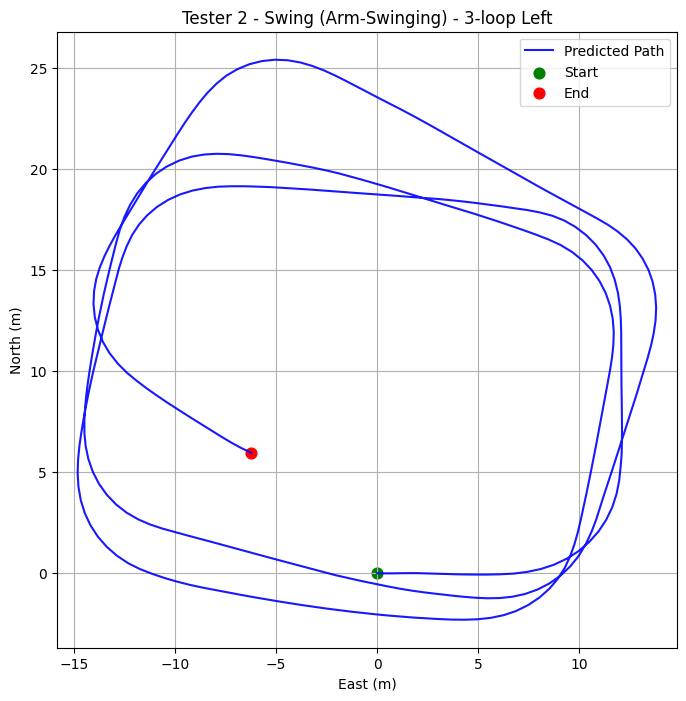

Start-End distance: 8.618 m
Heading Error (deg): -25.843 deg


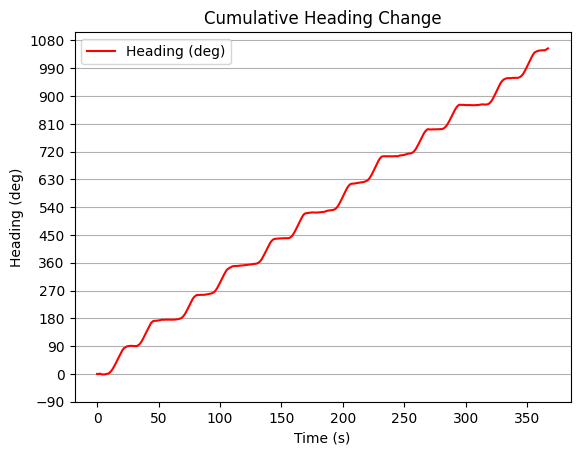

12/12 [==============================] - 0s 6ms/step


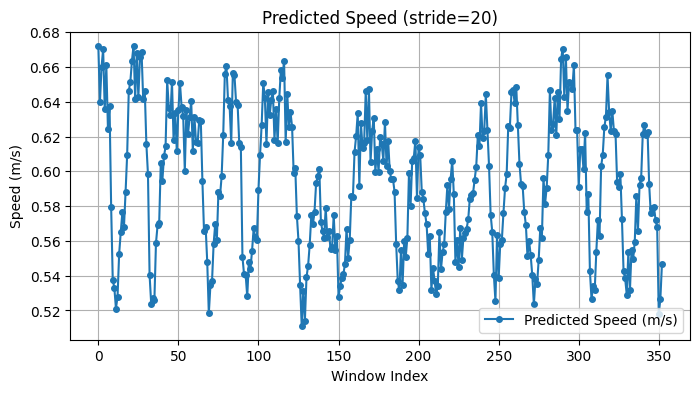

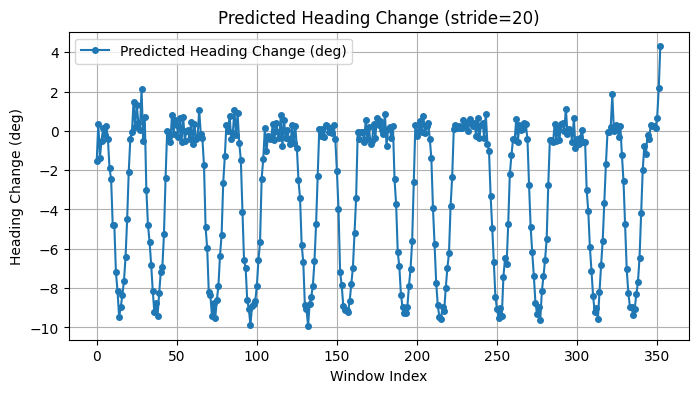

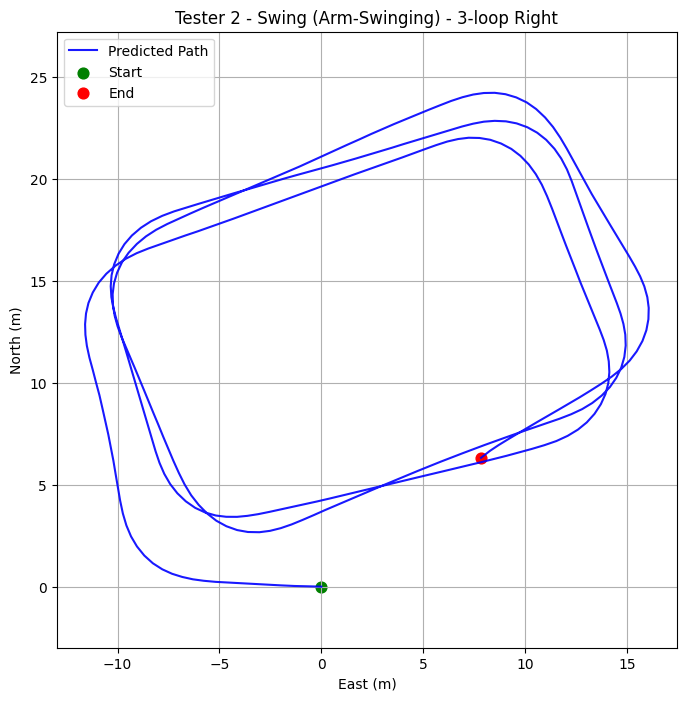

Start-End distance: 10.068 m
Heading Error (deg): -37.980 deg


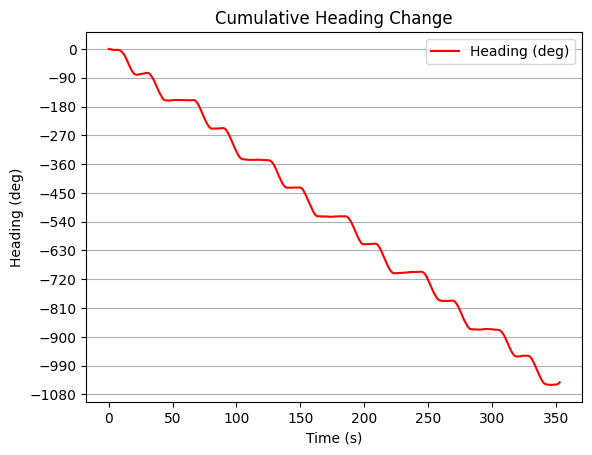

12/12 [==============================] - 0s 7ms/step


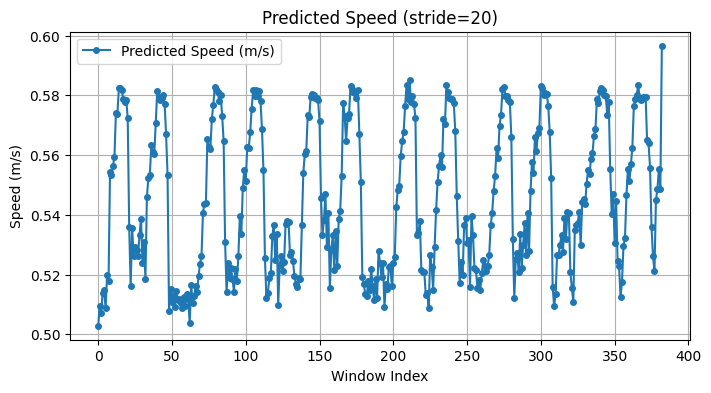

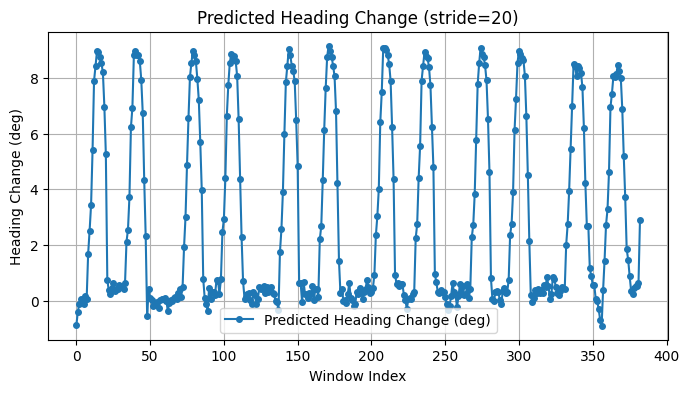

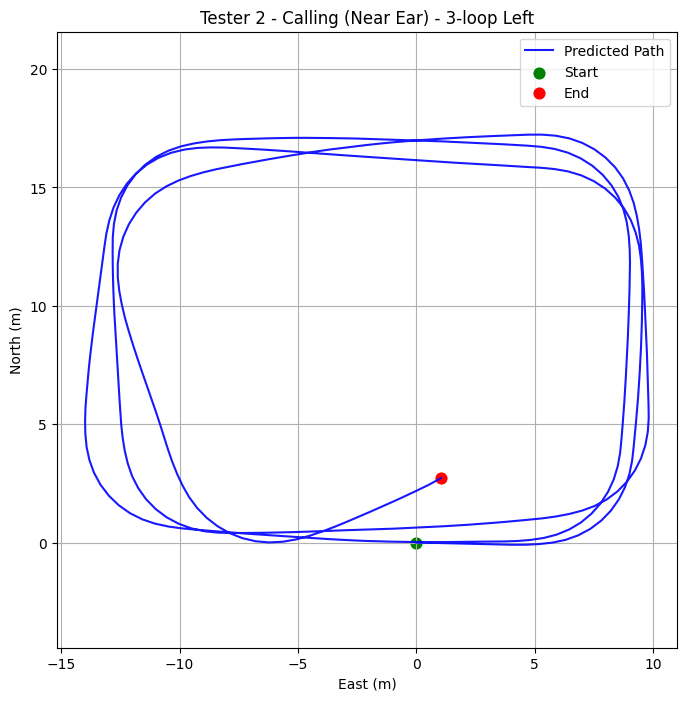

Start-End distance: 2.917 m
Heading Error (deg): 28.707 deg


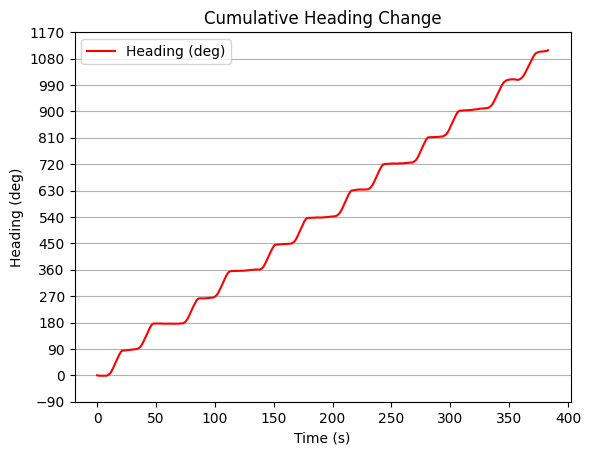

12/12 [==============================] - 0s 7ms/step


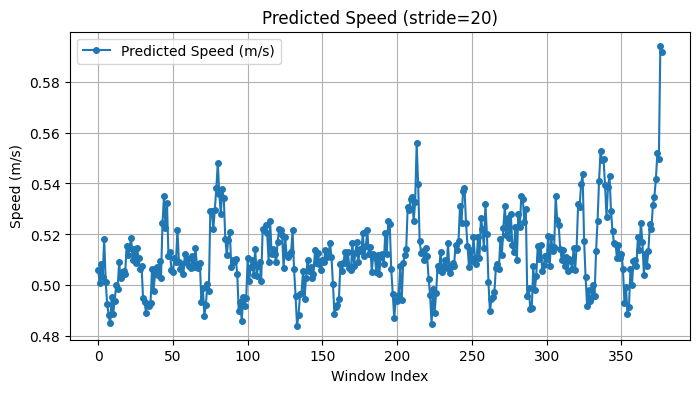

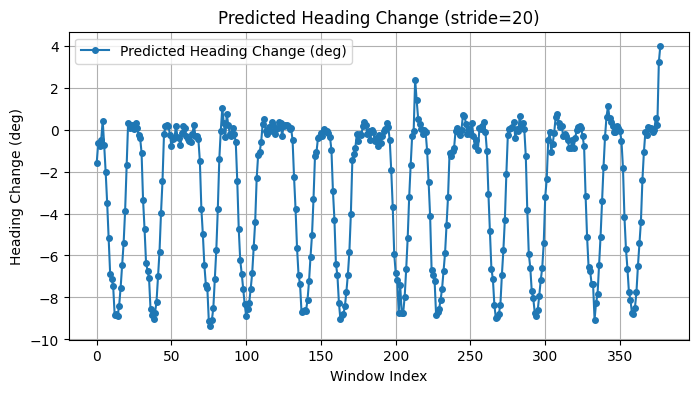

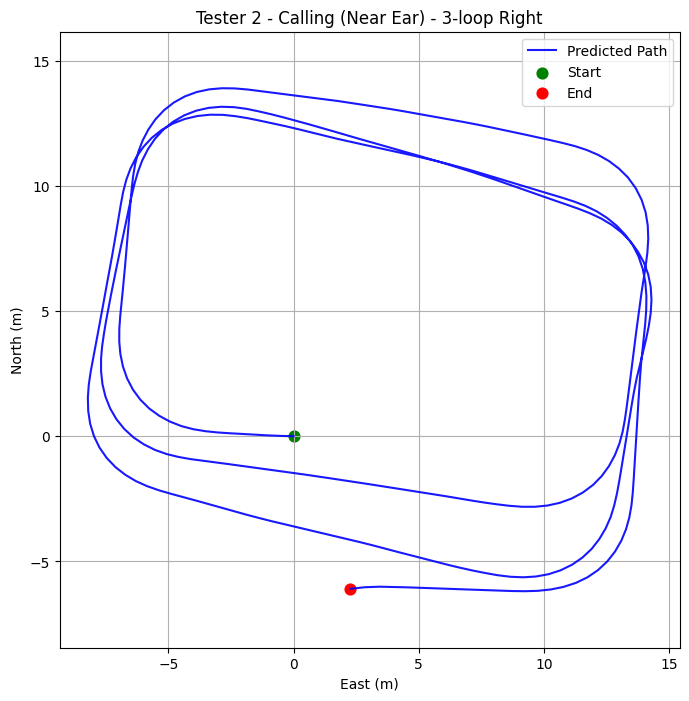

Start-End distance: 6.503 m
Heading Error (deg): -5.980 deg


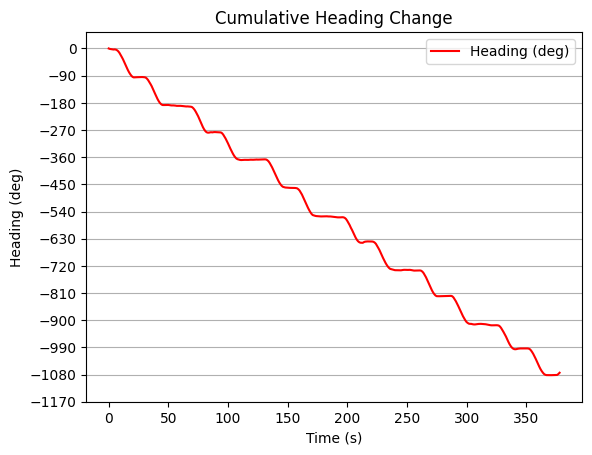

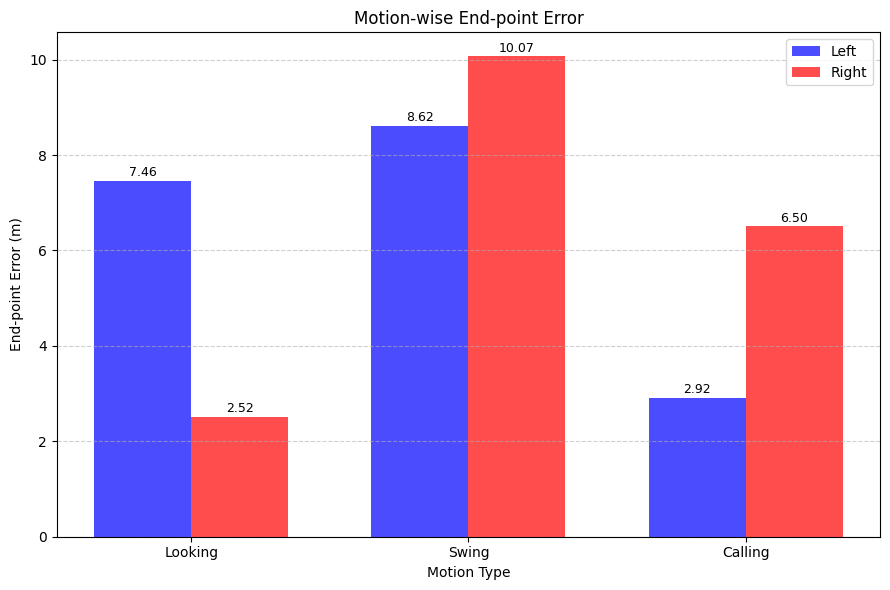

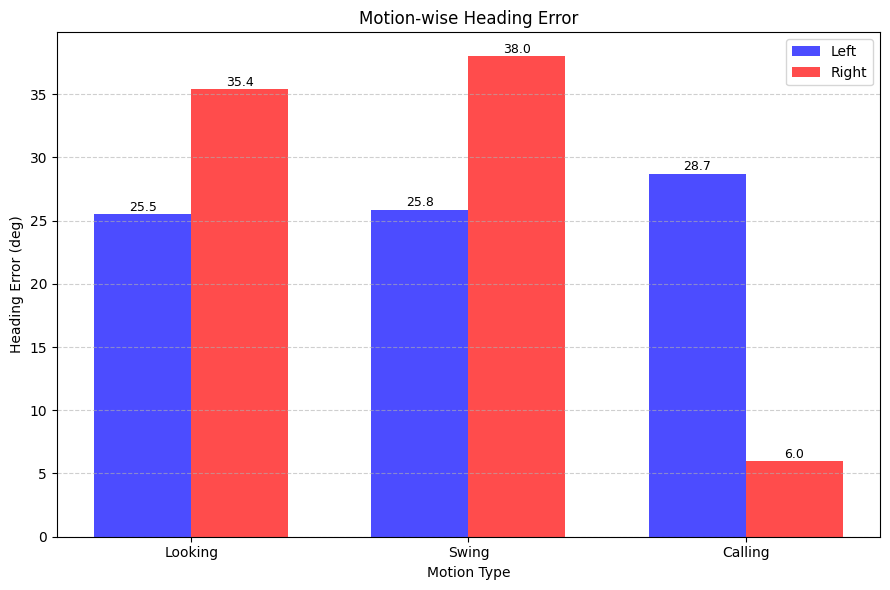

In [1]:
import os
import numpy as np
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor
import matplotlib.pyplot as plt
import random
import tensorflow as tf


# 시드 값 고정
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def plot_motion_errors(dist_errors, heading_errors, motions=None):
    """
    거리 오차(m)와 헤딩 오차(deg)를 각각 막대그래프로 출력
    motions: ["Looking", "Swing", "Calling"]
    """
    if motions is None:
        motions = ["Looking", "Swing", "Calling"]
    
    # 좌/우 분리 (순서: L, R, L, R, L, R)
    left_dist  = [dist_errors[i]   for i in range(0, len(dist_errors), 2)]
    right_dist = [dist_errors[i+1] for i in range(0, len(dist_errors), 2)]
    left_head  = [heading_errors[i]   for i in range(0, len(heading_errors), 2)]
    right_head = [heading_errors[i+1] for i in range(0, len(heading_errors), 2)]

    # ---------------------------
    # (1) End-point Error (m)
    # ---------------------------
    x = np.arange(len(motions))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 6))
    bars_left = ax.bar(x - width/2, left_dist, width, label='Left', color='blue', alpha=0.7)
    bars_right = ax.bar(x + width/2, right_dist, width, label='Right', color='red', alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(motions)
    ax.set_ylabel('End-point Error (m)')
    ax.set_xlabel('Motion Type')
    ax.set_title('Motion-wise End-point Error')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    for bars in [bars_left, bars_right]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # ---------------------------
    # (2) Heading Error (deg)
    # ---------------------------
    fig, ax = plt.subplots(figsize=(9, 6))
    bars_left = ax.bar(x - width/2, np.abs(left_head), width, label='Left', color='blue', alpha=0.7)
    bars_right = ax.bar(x + width/2, np.abs(right_head), width, label='Right', color='red', alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(motions)
    ax.set_ylabel('Heading Error (deg)')
    ax.set_xlabel('Motion Type')
    ax.set_title('Motion-wise Heading Error')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    for bars in [bars_left, bars_right]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

def main(): 
    BASE_DIR = os.getcwd()
    window_size = 200

    model_path = os.path.join(BASE_DIR, 'saved_models', 'ws200_20251022_164209.h5') #200, batch_size: 128
    trainer = ModelTrainer(window_size, num_features=8)
    trainer.load_model(model_path)
    
    predictor = TrajectoryPredictor(
        trainer.model,
        trainer.sensor_scalers,
        trainer.y_speed_scaler,
        trainer.y_hc_scaler,
        window_size=window_size
    )
    
    
    test_paths = [
          
         
        # os.path.join(BASE_DIR, "data", "testData_tester2", "looking_3loop_l01_jw.csv"),
        # os.path.join(BASE_DIR, "data", "testData_tester2", "looking_3loop_r01_jw.csv"),
        
        # os.path.join(BASE_DIR, "data", "testData_tester2", "swing_3loop_l01_jw.csv"),
        # os.path.join(BASE_DIR, "data", "testData_tester2", "swing_3loop_r01_jw.csv"),
        
        # os.path.join(BASE_DIR, "data", "testData_tester2", "calling_3loop_l02_jw.csv"),
        # os.path.join(BASE_DIR, "data", "testData_tester2", "calling_3loop_r03_jw.csv"),
        
        os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_3loop_l02.csv"),
        os.path.join(BASE_DIR, "data", "test_data", "looking", "test_looking_3loop_r01.csv"),
        
        os.path.join(BASE_DIR, "data", "test_data", "swing", "test_swing_3loop_l01.csv"),
        os.path.join(BASE_DIR, "data", "test_data", "swing", "test_swing_3loop_r02.csv"),
        
        os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_l02.csv"),
        os.path.join(BASE_DIR, "data", "test_data", "calling", "test_calling_3loop_r04.csv"),
    ]
    
    title_list = [
        "Indoor - Looking (Front-Holding) - 3-loop Left",
        "Indoor - Looking (Front-Holding) - 3-loop Right",
        "Indoor - Swing (Arm-Swinging) - 3-loop Left",
        "Indoor - Swing (Arm-Swinging) - 3-loop Right",
        "Indoor - Calling (Near Ear) - 3-loop Left",
        "Indoor - Calling (Near Ear) - 3-loop Right",
    ]
    
    
    looking_3loop_l01 = DataProcessor.load_and_preprocess_csv_test(test_paths[0], skiprows=100)
    looking_3loop_r01 = DataProcessor.load_and_preprocess_csv_test(test_paths[1], skiprows=100)
    swing_3loop_l01 = DataProcessor.load_and_preprocess_csv_test(test_paths[2], skiprows=100)
    swing_3loop_r01 = DataProcessor.load_and_preprocess_csv_test(test_paths[3], skiprows=100)
    calling_3loop_l01 = DataProcessor.load_and_preprocess_csv_test(test_paths[4], skiprows=100)
    calling_3loop_r01 = DataProcessor.load_and_preprocess_csv_test(test_paths[5], skiprows=100)
    
    
    results = [
        predictor.predict_and_plot_trajectory(looking_3loop_l01, False, "Tester 2 - Looking (Front-Holding) - 3-loop Left", plot_flag=False),
        predictor.predict_and_plot_trajectory(looking_3loop_r01, False, "Tester 2 - Looking (Front-Holding) - 3-loop Right", plot_flag=True),
        predictor.predict_and_plot_trajectory(swing_3loop_l01,   False, "Tester 2 - Swing (Arm-Swinging) - 3-loop Left",   plot_flag=False),
        predictor.predict_and_plot_trajectory(swing_3loop_r01,   False, "Tester 2 - Swing (Arm-Swinging) - 3-loop Right",  plot_flag=True),
        predictor.predict_and_plot_trajectory(calling_3loop_l01, False, "Tester 2 - Calling (Near Ear) - 3-loop Left",     plot_flag=False),
        predictor.predict_and_plot_trajectory(calling_3loop_r01, False, "Tester 2 - Calling (Near Ear) - 3-loop Right",    plot_flag=True),
    ]

    dist_errors, heading_errors = zip(*results)
    dist_errors = list(dist_errors)
    heading_errors = list(heading_errors)


    plot_motion_errors(dist_errors, heading_errors, motions=["Looking", "Swing", "Calling"])


if __name__ == '__main__':
    main() 
    


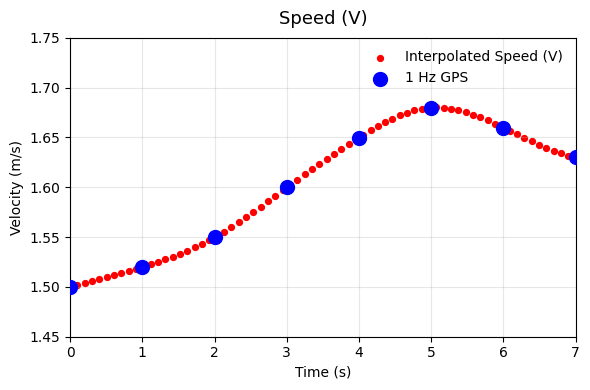

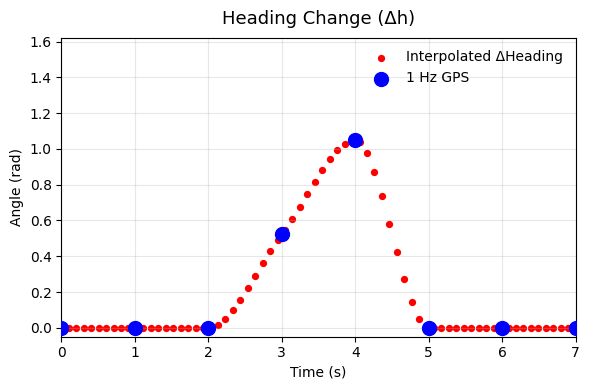

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, PchipInterpolator

# -----------------------------
# 1Hz GPS time points
# -----------------------------
t_gps = np.arange(0, 8, 1)  # 0..7 s (1 Hz)

# -----------------------------
# GPS-derived labels
# -----------------------------
# Speed: ~1.5–1.7 m/s gentle variation
v_gps = np.array([1.50, 1.52, 1.55, 1.60, 1.65, 1.68, 1.66, 1.63])

# Heading change (cumulative angle): 2–4 s → 90° (π/2 rad), then hold
dh_gps = np.zeros_like(t_gps, dtype=float)
dh_gps[2:5] = np.linspace(0, np.pi/3, 3)  # t=2,3,4: 0 → π/2
#dh_gps[5:] = dh_gps[4]                    # hold after t>=5 to avoid oscillation

# -----------------------------
# Interpolation grids
# -----------------------------
t_dense = np.linspace(0, 7, 70)  # 0.1 s (10 Hz)

# Speed: cubic is fine (smooth)
v_interp = interp1d(t_gps, v_gps, kind='cubic')(t_dense)

# Δh: use PCHIP (shape-preserving monotone) to avoid overshoot
pchip = PchipInterpolator(t_gps, dh_gps, extrapolate=True)
dh_interp = pchip(t_dense)

# (Optional) clip Δh range for extra safety (here 0..π/2)
dh_interp = np.clip(dh_interp, 0.0, np.pi/2)

# -----------------------------
# Plot separately
# -----------------------------
# 1) Speed
plt.figure(figsize=(6, 4))
plt.scatter(t_dense, v_interp, c='r', s=5, linewidth=3, label='Interpolated Speed (V)')
plt.scatter(t_gps, v_gps, c='b', s=100, zorder=5, label='1 Hz GPS')
plt.title("Speed (V)", fontsize=13, pad=10)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.xlim(0, 7)
plt.ylim(1.45, 1.75)
plt.tight_layout()
plt.show()

# 2) Heading Change (Δh)
plt.figure(figsize=(6, 4))
plt.scatter(t_dense, dh_interp, color='r', s=5, linewidth=3, label='Interpolated ΔHeading')
plt.scatter(t_gps, dh_gps, color='b', s=100, zorder=5, label='1 Hz GPS')
plt.title("Heading Change (Δh)", fontsize=13, pad=10)
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.xlim(0, 7)
plt.ylim(-0.05, np.pi/2 + 0.05)
plt.tight_layout()
plt.show()
